In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
!which python
!which conda
!python -c "import platform; print(platform.machine())"

/Users/su781/miniforge3/envs/trajopt/bin/python
/Users/su781/opt/anaconda3/condabin/conda
arm64


In [3]:
import pickle
import numpy as np
from jax import jacfwd, jit, config

# import jax
# import jax.numpy as jnp
# from jax import jit, jacfwd, vmap, lax, config
# from jax.lax import cond
# from jaxlib.xla_extension import ArrayImpl
config.update("jax_enable_x64", True)


In [4]:
from pc_glob import x_val, y_val, w_ptr_val, A, m
from pc_fcns import comp, convex_jax, smooth
from pc_parse import generate_lin_problem, generate_cvx_problem
from pc_solve import prox_linear
from pc_plot import plot

In [5]:
fcns_jit = dict()
fcns_jit['comp_jit'] = jit(comp).lower(x_val).compile()
fcns_jit['g_comp_jit'] = jit(jacfwd(comp)).lower(x_val).compile()
fcns_jit['convex_jax_jit'] = jit(convex_jax).lower(x_val).compile()
fcns_jit['g_smooth_jit'] = jit(jacfwd(smooth)).lower(y_val).compile()

In [6]:
w_ptr_val = 1e-3
dt_lin, x_val_list_lin, J_list_lin, dx_list_lin, times_lin = prox_linear(x_val, w_ptr_val, fcns_jit, prb_type='lin')

# Replace with your actual solver output
results_lin = {
    "dt": dt_lin,
    "x_val_list": x_val_list_lin,
    "J_list": J_list_lin,
    "dx_list": dx_list_lin,
    "times": times_lin,
}

with open("results_lin.pkl", "wb") as f:
    pickle.dump(results_lin, f)

DPP:  True
Iter 0, J_xk: 3.0933, J_diff: 2.1354, L_diff: 1.3841, Ratio: 1.5428, w_ptr: 0.0010, dt: 0.0895
Iter 1, J_xk: 0.9579, J_diff: 1.0328, L_diff: 0.7105, Ratio: 1.4536, w_ptr: 0.0005, dt: 0.0028
Iter 2, J_xk: -0.0749, J_diff: 0.2932, L_diff: 0.2588, Ratio: 1.1330, w_ptr: 0.0003, dt: 0.0014
Iter 3, J_xk: -0.3681, J_diff: -0.6482, L_diff: 0.3458, Ratio: -1.8743, w_ptr: 0.0001, dt: 0.0013
-----------------------------------Reject-----------------------------------
Iter 3, J_xk: -0.3681, J_diff: -0.3630, L_diff: 0.2815, Ratio: -1.2894, w_ptr: 0.0003, dt: 0.0013
-----------------------------------Reject-----------------------------------
Iter 3, J_xk: -0.3681, J_diff: -0.1371, L_diff: 0.2344, Ratio: -0.5847, w_ptr: 0.0005, dt: 0.0014
-----------------------------------Reject-----------------------------------
Iter 3, J_xk: -0.3681, J_diff: -0.1262, L_diff: 0.1789, Ratio: -0.7051, w_ptr: 0.0010, dt: 0.0016
-----------------------------------Reject-----------------------------------
Ite

In [7]:
# 3.4078418775700685 0.13631367510280273
# 2.8243735188379575 0.22847140495291593
# 3.050045686841768 0.8110966264349737
# 1.7417672025275708 0.9124651754579051
# 2.292992733209795 5.517409070131979
# 9.849437662798461 41.031464285257215
# 2.621879646537526 100.76825511259757
# 14.808307417628757 105.70856075918228
# 17.489311090313382 53936.71236191007
# 4452.389382414841 34202080.961300835
# 919.6124895518516 359715309.6123808

# print(np.max(grad_hg.value), np.max(a2))


In [8]:
w_ptr_val = 1e-8
dt_cvx, x_val_list_cvx, J_list_cvx, dx_list_cvx, times_cvx = prox_linear(x_val, w_ptr_val, fcns_jit, prb_type='cvx')

# Replace with your actual solver output
results_cvx = {
    "dt": dt_cvx,
    "x_val_list": x_val_list_cvx,
    "J_list": J_list_cvx,
    "dx_list": dx_list_cvx,
    "times": times_cvx,
}

with open("results_cvx.pkl", "wb") as f:
    pickle.dump(results_cvx, f)

DPP:  True
Iter 0, J_xk: 3.0933, J_diff: 3.3188, L_diff: 2.7143, Ratio: 1.2227, w_ptr: 0.0000, dt: 0.0262
Iter 1, J_xk: -0.2255, J_diff: 0.1419, L_diff: 0.0720, Ratio: 1.9705, w_ptr: 0.0000, dt: 0.0013
Iter 2, J_xk: -0.3674, J_diff: 0.0210, L_diff: 0.0157, Ratio: 1.3384, w_ptr: 0.0000, dt: 0.0020
Iter 3, J_xk: -0.3884, J_diff: 0.0031, L_diff: 0.0014, Ratio: 2.2411, w_ptr: 0.0000, dt: 0.0014
Iter 4, J_xk: -0.3915, J_diff: 0.0054, L_diff: 0.0021, Ratio: 2.5545, w_ptr: 0.0000, dt: 0.0014
Iter 5, J_xk: -0.3969, J_diff: 0.0104, L_diff: 0.0039, Ratio: 2.6432, w_ptr: 0.0000, dt: 0.0012
Iter 6, J_xk: -0.4073, J_diff: 0.0190, L_diff: 0.0068, Ratio: 2.7952, w_ptr: 0.0000, dt: 0.0012
Iter 7, J_xk: -0.4263, J_diff: 0.0305, L_diff: 0.0104, Ratio: 2.9474, w_ptr: 0.0000, dt: 0.0013
Iter 8, J_xk: -0.4568, J_diff: 0.0234, L_diff: 0.0108, Ratio: 2.1679, w_ptr: 0.0000, dt: 0.0016
Iter 9, J_xk: -0.4801, J_diff: 0.0017, L_diff: 0.0015, Ratio: 1.1171, w_ptr: 0.0000, dt: 0.0014
Iter 10, J_xk: -0.4819, J_diff

In [9]:
with open("results_lin.pkl", "rb") as f:
    results_lin = pickle.load(f)

with open("results_cvx.pkl", "rb") as f:
    results_cvx = pickle.load(f)

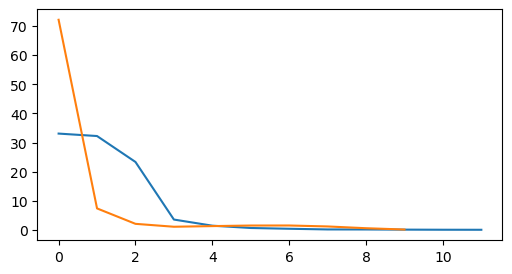

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
plt.plot(results_lin['dx_list'])
plt.plot(results_cvx['dx_list'])

dt_lin     :  0.0031
dt_cvx     :  0.0035
ratio      :  1.1408

dt_lin_sum :  0.1982
dt_cvx_sum :  0.0435
ratio      :  4.5556

J_list_lin :  -0.48160000000000003
J_list_cvx :  -0.48190000000000005


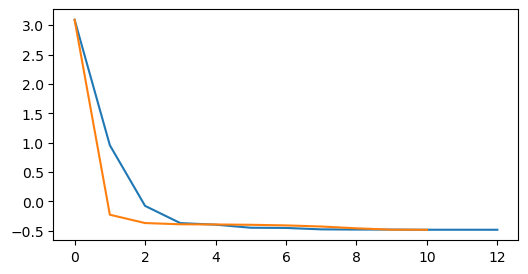

In [11]:
print('dt_lin     : ', round(np.average(np.array(results_lin['times'])), 4))
print('dt_cvx     : ', round(np.average(np.array(results_cvx['times'])), 4))
print('ratio      : ', round(np.average(np.array(results_cvx['times']))/np.average(np.array(results_lin['times'])), 4))
print('')
print('dt_lin_sum : ', round(results_lin['dt'], 4))
print('dt_cvx_sum : ', round(results_cvx['dt'], 4))
print('ratio      : ', round(results_lin['dt']/results_cvx['dt'], 4))
print('')
print('J_list_lin : ', results_lin['J_list'][-1].round(4))
print('J_list_cvx : ', results_cvx['J_list'][-1].round(4))

plot(results_lin['J_list'][:], results_cvx['J_list'][:], results_lin['x_val_list'][:], results_cvx['x_val_list'][:], fcns_jit)

In [12]:
condition_numbers = [np.linalg.cond(M) for M in A]

for i, cond_num in enumerate(condition_numbers, start=1):
    print(f"Matrix {i}: condition number = {cond_num:.6e}")

Matrix 1: condition number = inf
Matrix 2: condition number = inf
Matrix 3: condition number = inf
Matrix 4: condition number = inf
Matrix 5: condition number = inf
Matrix 6: condition number = inf
Matrix 7: condition number = inf
Matrix 8: condition number = inf
Matrix 9: condition number = inf
Matrix 10: condition number = inf
Matrix 11: condition number = inf


In [13]:
sc = 1/100
A_mat = sc * A[0][:2, :2]

def _quad_affine(x):
    return 0.5 * (x @ A_mat @ x)

/var/folders/11/hzqn0f2j39lc0y5rrxhy48600000gn/T/ipykernel_40325/358781326.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


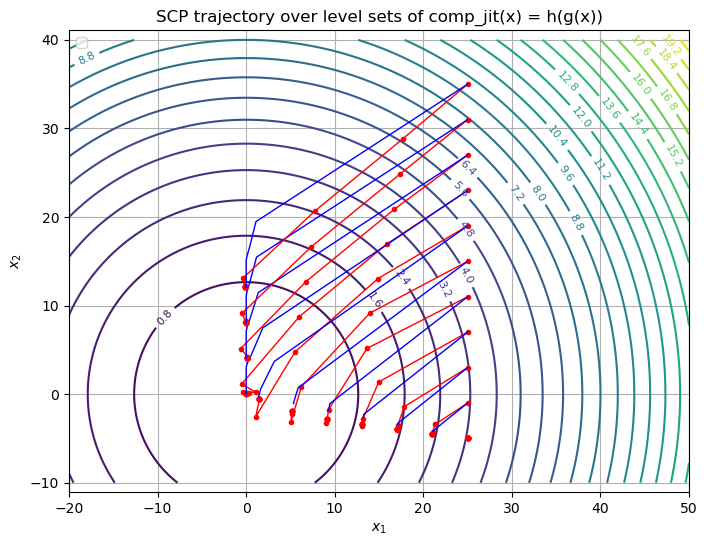

In [14]:
x_vals = np.array(x_val_list_lin)
x_vals_cvx = np.array(x_val_list_cvx)

# Create a grid for plotting level sets
x1 = np.linspace(-20, 50, 500)
x2 = np.linspace(-10, 40, 500)
X1, X2 = np.meshgrid(x1, x2)
Z = np.zeros_like(X1)

# Evaluate comp_jit(x) on the grid
for i in range(X1.shape[0]):
    for j in range(X1.shape[1]):
        x_ij = np.array([X1[i, j], X2[i, j]])
        Z[i, j] = _quad_affine(x_ij)

# Plot level sets and SCP trajectory
plt.figure(figsize=(8, 6))
CS = plt.contour(X1, X2, Z, levels=30, cmap='viridis')
plt.clabel(CS, inline=1, fontsize=8)
for i in range(m):
    plt.plot(x_vals[:, i*2], x_vals[:, i*2+1], 'r.-', linewidth=1)
    plt.plot(x_vals_cvx[:, i*2], x_vals_cvx[:, i*2+1], c='blue', ls='-', linewidth=1)

plt.title("SCP trajectory over level sets of comp_jit(x) = h(g(x))")
# plt.xlim(-1.0, 1.5)
# plt.ylim(-1.1, 1.9)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

/var/folders/11/hzqn0f2j39lc0y5rrxhy48600000gn/T/ipykernel_40325/3943715728.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


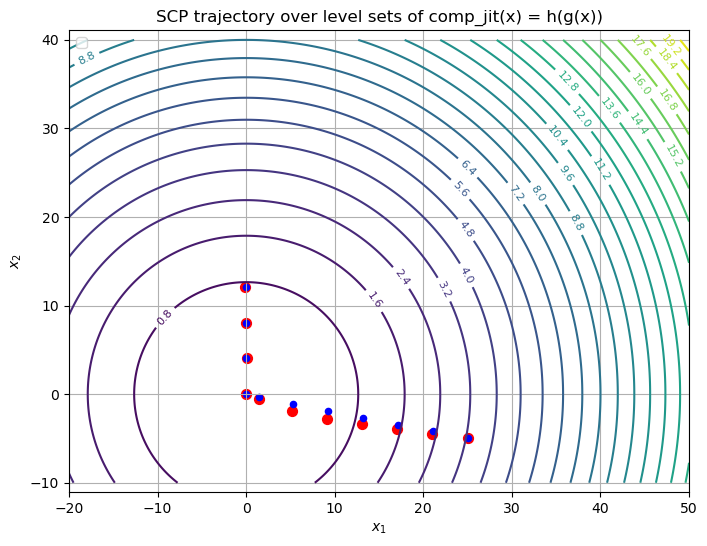

In [15]:
# Plot level sets and SCP trajectory
plt.figure(figsize=(8, 6))
CS = plt.contour(X1, X2, Z, levels=30, cmap='viridis')
plt.clabel(CS, inline=1, fontsize=8)
for i in range(m):
    plt.scatter(x_vals[-1, i*2], x_vals[-1, i*2+1], c='red', s=50)
    plt.scatter(x_vals_cvx[-1, i*2], x_vals_cvx[-1, i*2+1], c='blue', s=20)

plt.title("SCP trajectory over level sets of comp_jit(x) = h(g(x))")
# plt.xlim(-1.0, 1.5)
# plt.ylim(-1.1, 1.9)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

In [16]:
# Eventually, if feasible then will occur

In [17]:
# xxx

## If we can use smooth formulation for MIP problems

In [18]:
# import cvxpy as cp
# import numpy as np
# import matplotlib.pyplot as plt

# # Constants
# a = -1
# b = 5

# def f(x):
#     return (x - a)**2 - 15
# def gf(x):
#     return 2*(x - a)

# def g(x):
#     return (x - b)**2
# def gg(x):
#     return 2*(x - b)

# def h(x,y):
#     return y * f(x) + (1-y) * g(x)


# def h_lin(x, y, x_k, y_k):
#     return h(x_k, y_k) + y_k * (gf(x_k) * (x - x_k)) + (1 - y_k)*(gg(x_k) * (x - x_k))  + (f(x_k) - g(x_k)) * (y - y_k) 

# def h_cvx(x, y, x_k, y_k):
#     return h(x_k, y_k) + y_k * (f(x) - f(x_k)) + (1 - y_k)*(g(x) - g(x_k))  + (f(x_k) - g(x_k)) * (y - y_k) 

# h_s = h_lin
# h_s = h_cvx
# w_ptr = 0.08015

In [19]:
# # Define the optimization variable
# x_k0 = 5.5
# y_k0 = 0.5

# x_k = x_k0
# y_k = y_k0

# x_list = [x_k]
# y_list = [y_k]
# h_val_list = [h(x_k, y_k)]
# print(f"Iteration {-1}: x_k = {x_k}, y_k = {y_k}, h(x_k, y_k) = {h(x_k, y_k)}")

# for ite in range(50):

#     x = cp.Variable()
#     y = cp.Variable()

#     # Define the optimization problem
#     tr_x = (x - x_k)**2
#     tr_y = 100*(y - y_k)**2
#     tr = w_ptr * (tr_x + tr_y)
#     objective = cp.Minimize(h_s(x, y, x_k, y_k) + tr)
#     problem = cp.Problem(objective, 
#                         [y >= 0,
#                         y <= 1],
#                         )

#     # Solve the problem
#     problem.solve(solver='MOSEK')

#     # Update x_k and y_k
#     x_k = x.value
#     y_k = y.value

#     # Store the values
#     x_list.append(x_k)
#     y_list.append(y_k)
#     h_val_list.append(h(x_k, y_k))

#     # Print the results
#     print(f"Iteration {ite}: x_k = {x_k}, y_k = {y_k}, h(x_k, y_k) = {h(x_k, y_k)}")

# x_arr = np.array(x_list)
# y_arr = np.array(y_list)
# h_val_arr = np.array(h_val_list)

# # Print result
# print('X:', x_arr)
# print('Y:', y_arr)
# print('H:', h_val_arr)
# # print(f"Optimal x: {x.value}")
# # print(f"Optimal y: {y.value}")
# # print(f"Optimal h(x): {h(x.value, y.value)}")


In [20]:
# # Grid for x and y
# x_vals = np.linspace(-2, 6, 200)
# y_vals = np.linspace(0, 1, 200)
# X, Y = np.meshgrid(x_vals, y_vals)

# # x_lin = x_k0
# # y_lin = y_k0

# # x_lin = 2
# # y_lin = 0

# # x_lin = 5
# # y_lin = 1

# x_lin = -1
# y_lin = 0

# # Compute original and convexified h
# H = h(X, Y)
# H_s = h_s(X, Y, x_lin, y_lin)





# # Plot level sets
# plt.figure(figsize=(12, 5))

# # Contour of h
# plt.subplot(1, 2, 1)
# cont1 = plt.contourf(X, Y, H, levels=50, cmap='viridis')
# plt.colorbar(cont1)
# plt.scatter(x_arr, y_arr, c='white', label='Iterates', s=100)
# plt.plot(x_arr, y_arr, c='white', lw=0.5)
# plt.title(r"Level sets of $h(x, y)$")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.plot(x_lin, y_lin, 'ro', label="Linearization point")
# # ax = plt.gca()
# # ax.set_aspect('equal', adjustable='box')
# plt.legend()

# # Contour of h_s
# plt.subplot(1, 2, 2)
# cont2 = plt.contourf(X, Y, H_s, levels=50, cmap='plasma')
# plt.colorbar(cont2)
# plt.title(r"Level sets of $h_{cvx}(x, y)$")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.plot(x_lin, y_lin, 'ro', label="Linearization point")
# # ax = plt.gca()
# # ax.set_aspect('equal', adjustable='box')
# plt.legend()

# plt.tight_layout()
# plt.show()







# # 3D plots
# fig = plt.figure(figsize=(12, 5))

# # 3D of h
# ax1 = fig.add_subplot(121, projection='3d')
# ax1.plot_surface(X, Y, H, cmap='viridis', edgecolor='none', alpha=0.9)
# ax1.set_title(r'$h(x, y)$')
# ax1.set_xlabel('x')
# ax1.set_ylabel('y')
# ax1.set_zlabel('h')

# # 3D of h_s
# ax2 = fig.add_subplot(122, projection='3d')
# ax2.plot_surface(X, Y, H_s, cmap='plasma', edgecolor='none', alpha=0.9)
# ax2.set_title(r'$h_{\mathrm{cvx}}(x, y)$')
# ax2.set_xlabel('x')
# ax2.set_ylabel('y')
# ax2.set_zlabel('h_s')

# plt.tight_layout()
# plt.show()


In [21]:
# plt.plot(x_arr)

In [22]:
# plt.plot(y_arr)


In [23]:
# # Optional: Plot the functions
# x_vals = np.linspace(-2, 6, 500)
# f_vals = f(x_vals)
# g_vals = g(x_vals)
# h_vals = 0.5 * f_vals + (1 - 0.5) * g_vals

# plt.figure(figsize=(8, 5))
# plt.plot(x_vals, f_vals, label=r'$f(x) = (x - a)^2$', color='blue')
# plt.plot(x_vals, g_vals, label=r'$g(x) = (x - b)^2$', color='green')
# plt.plot(x_vals, h_vals, label=r'$h(x) = y f(x) + (1-y) g(x)$', color='red')
# plt.axvline(x.value, color='black', linestyle='--', label='Optimal x')
# plt.title("Minimization of x subject to h(x)")
# plt.xlabel("x")
# plt.ylabel("Function values")
# plt.legend()
# plt.grid(True)
# plt.tight_layout()
# plt.show()